# Tutorial: Transporte de impurezas en EAST con Aurora
**Vicente Sepúlveda**

Este notebook es una guía práctica para entender cómo usar la librería `aurora` para simular transporte de impurezas 1.5D en tokamaks y cómo se conecta con diagnósticos experimentales (espectrometría). 

Está basado en el modelo y las herramientas que usé durante mi trabajo de práctica de licenciatura analizando descargas del tokamak EAST.


## 1. Por qué nos importan las impurezas

En fusión queremos hacer reaccionar núcleos de deuterio y tritio ($D-T$). Para que el reactor sea autosuficiente ($P_{\text{fus}} \ge P_{\text{loss}}$), la potencia generada tiene que ganarle a las pérdidas térmicas y de radiación.

La potencia de fusión para un plasma $D-T$ viene dada por:

$$P_{\text{fus}} = \frac{n^2}{4} \langle \sigma v \rangle E_{\text{fus}}$$

donde $n$ es la densidad ($n_D = n_T = n/2$), $\langle \sigma v \rangle$ es la reactividad y $E_{\text{fus}} = 17.6\ \text{MeV}$. Las pérdidas de energía se modelan con el tiempo de confinamiento $\tau_E$:

$$P_{\text{loss}} = \frac{3 n k_B T}{\tau_E}$$

Pidiendo $P_{\text{fus}} \ge P_{\text{loss}}$ llegamos al **criterio de Lawson**:

$$n \tau_E \ge \frac{12\, k_B T}{\langle \sigma v \rangle E_{\text{fus}}}$$

A la temperatura típica de operación ($T \approx 10\ \text{keV}$), esto se traduce en el conocido **triple producto de fusión**:

$$n T \tau_E \gtrsim 3 \times 10^{21}\ \text{m}^{-3}\ \text{keV}\ \text{s}$$

De todas las configuraciones magnéticas (stellarators, pinches, espejos), los tokamaks son los que han llegado más cerca de este valor (por eso ITER en Francia y reactores como EAST y BEST en China son tokamaks).

### El problema de las impurezas
Cualquier átomo en el plasma que no sea el combustible ($D$ o $T$) es una **impureza**. Entran principalmente por la interacción del plasma con las paredes del reactor (tungsteno, molibdeno, acero, etc.).

El problema con los iones pesados (como $W$ o $Fe$) es que a las temperaturas del núcleo no se ionizan completamente; retienen electrones ligados. En cada colisión con electrones del plasma, esos electrones se excitan y luego emiten fotones que escapan del plasma. Básicamente, actúan como sumideros de energía que enfrían el núcleo:
1. **Pérdidas por radiación:** La potencia radiada escala como $P_{\text{rad}} \propto n_e n_Z R(T_e)$. Con una fracción ínfima de tungsteno ($n_W/n_e \sim 10^{-4}$), el centro se enfría tan rápido que el plasma puede colapsar (disrupción).
2. **Dilución:** Cada ion pesado mete muchos electrones al plasma pero casi nada a la presión del combustible, reduciendo la potencia de fusión neta.

Por eso nos interesa entender cómo se mueven las impurezas en el plasma (transporte) y cómo sacarlas (por ejemplo, aplicando calentamiento ECRH en el centro para generar *pump-out*).

Para modelar esto usamos **Aurora**, un código en Python (desarrollado por Francesco Sciortino) que corre el transporte 1.5D en ~20-50 ms en memoria, lo que permite hacer simulaciones rápidas y ajustar perfiles contra datos experimentales.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate
import scipy.interpolate
import warnings
import pandas as pd

import aurora

# aurora.read_adf15 hace un chained-assignment interno que pandas >= 3.0 marca
# como ChainedAssignmentError (advertencia, no error); es inofensivo, se silencia
# aquí para no ensuciar la salida de las celdas que cargan archivos ADF15.
warnings.filterwarnings('ignore', category=pd.errors.ChainedAssignmentError)

print(f"Versión de Aurora : {aurora.__version__}")
print(f"Versión de Numpy  : {np.__version__}")

# Configuración estética consistente para gráficos de calidad de publicación
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
    'figure.figsize': (8.5, 4.8),
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
    'lines.linewidth': 2.0
})
print("Entorno configurado correctamente.")

Versión de Aurora : 3.0.6
Versión de Numpy  : 1.26.4
Entorno configurado correctamente.


## 2. Datos atómicos (ADAS) y equilibrio coronal

### 2.1 Tasas de ionización y recombinación (equilibrio coronal)

Para saber qué fracción de cada ion está ionizada a una cierta temperatura y densidad, Aurora usa las tablas de ADAS:
* **SCD (ADF11):** tasas de ionización efectiva $S(n_e, T_e)$.
* **ACD (ADF11):** tasas de recombinación efectiva $\alpha(n_e, T_e)$.



Vamos a cargar datos para Hierro ($Z=26$), la impureza principal analizada en la tesis.

Datos atómicos cargados para Hierro (Z=26):
  Tipo: SCD  | Estados de carga: 26 | Grilla Te: 48 pts | Grilla ne: 26 pts
  Tipo: ACD  | Estados de carga: 26 | Grilla Te: 48 pts | Grilla ne: 26 pts


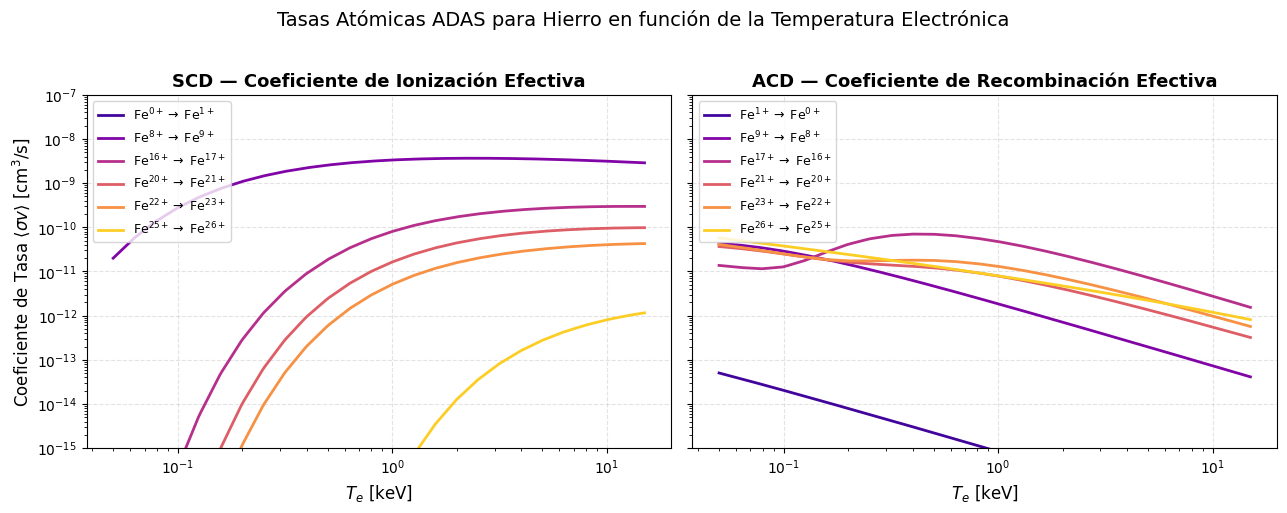

In [2]:
# Cargar datos atómicos ADF11 de Hierro (SCD para ionización, ACD para recombinación)
# Aurora los descarga automáticamente de OPEN-ADAS si no están presentes localmente
atom_data = aurora.atomic.get_atom_data('Fe', files=['scd', 'acd'])

print("Datos atómicos cargados para Hierro (Z=26):")
for key, val in atom_data.items():
    print(f"  Tipo: {key.upper():4s} | Estados de carga: {val.logdata.shape[0]} | "
          f"Grilla Te: {len(val.logT)} pts | Grilla ne: {len(val.logNe)} pts")

# Evaluemos las tasas en un rango amplio de temperatura electrónica Te (50 eV a 15 keV) a ne fija
Te_eval_eV = np.logspace(np.log10(50), np.log10(1.5e4), 250)
ne_eval_cm3 = 2.5e13  # densidad representativa del núcleo de EAST

logTe = np.log10(Te_eval_eV)
logne = np.log10(np.full_like(Te_eval_eV, ne_eval_cm3))

# aurora.atomic.interp_atom_prof con x_multiply=False devuelve el coeficiente [cm^3/s]
S_rates = aurora.atomic.interp_atom_prof(atom_data['scd'], logne, logTe, x_multiply=False)  # shape: (len(Te), Z)
R_rates = aurora.atomic.interp_atom_prof(atom_data['acd'], logne, logTe, x_multiply=False)  # shape: (len(Te), Z)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# Graficar ionización y recombinación para estados seleccionados (incluye Fe22+, la línea Fe XXIII de la tesis)
charge_states_to_plot = [0, 8, 16, 20, 22, 25]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(charge_states_to_plot)))

for q, c in zip(charge_states_to_plot, colors):
    ax1.plot(Te_eval_eV / 1e3, S_rates[:, q], color=c, label=f'Fe$^{{{q}+}} \\to$ Fe$^{{{q+1}+}}$')
    ax2.plot(Te_eval_eV / 1e3, R_rates[:, q], color=c, label=f'Fe$^{{{q+1}+}} \\to$ Fe$^{{{q}+}}$')

ax1.set_title("SCD — Coeficiente de Ionización Efectiva", fontweight='bold')
ax2.set_title("ACD — Coeficiente de Recombinación Efectiva", fontweight='bold')

for ax in (ax1, ax2):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$T_e$ [keV]')
    ax.set_ylim(1e-15, 1e-7)
    ax.legend(fontsize=9, loc='upper left')

ax1.set_ylabel(r'Coeficiente de Tasa $\langle \sigma v \rangle$ [$\mathrm{cm}^3/\mathrm{s}$]')
plt.suptitle("Tasas Atómicas ADAS para Hierro en función de la Temperatura Electrónica", y=1.02)
plt.tight_layout()
plt.show()

### 2.2 Presencia radial de los estados de carga en el plasma

En un tokamak, la temperatura no es constante: es máxima en el centro magnético ($\rho=0$) y decae progresivamente hacia el borde ($\rho=1$).

Como cada estado de carga requiere una cierta energía térmica para ionizarse y subsistir, los iones se distribuyen a lo largo del radio formando (*shells*):
* **En el centro caliente ($\rho \to 0$):** dominan los estados más ionizados (como $Fe^{24+}$, cercano al H-like, o $W^{50+}$ y superiores).
* **En el radio medio ($\rho \approx 0.5 - 0.8$):** dominan estados con capas cerradas intermedias (como la capa Ne-like $Fe^{16+}$, o la región del W-UTA en Tungsteno).
* **Cerca del borde frío ($\rho \to 1.0$):** se concentran los estados de baja carga ($1+$ a $4+$).

El siguiente gráfico muestra la **intensidad / presencia relativa de cada ion** ($f_z^{(q)} = n_z^{(q)} / n_{z,\text{tot}}$) en función del radio normalizado $\rho_p$.

**Usa el slider de temperatura central ($T_{e,0}$)** para ver cómo al calentar el núcleo (por ejemplo con microondas ECRH), las capas de iones se desplazan hacia el exterior del plasma. También puedes cambiar de elemento (**Fe**, **W**) con el selector:

In [3]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

# Cargar datos atómicos ADAS para los elementos relevantes en EAST (Fe, W)
if 'atom_cache' not in globals():
    import aurora
    atom_cache = {
        'Fe': aurora.atomic.get_atom_data('Fe', files=['scd', 'acd']),
        'W': aurora.atomic.get_atom_data('W', files=['scd', 'acd']),
    }
    # Por compatibilidad con las siguientes celdas de transporte con Hierro
    atom_data = atom_cache['Fe']

# Grilla radial normalizada desde el eje (rho=0) hasta la separatriz (rho=1)
rho_grid = np.linspace(0, 1.0, 150)
ne_prof_cm3 = 4.2e13 * (1.0 - 0.88 * rho_grid**4)

def plot_radial_presence(element='Fe', Te_core_keV=2.2):
    """Grafica el perfil de temperatura Te(rho) y la presencia radial de los estados de carga en EAST."""
    Te_prof_eV = Te_core_keV * 1e3 * (1.0 - rho_grid**2)**1.6 + 35.0
    atom_data_elem = atom_cache[element]
    
    _, frac_rad = aurora.atomic.get_frac_abundances(atom_data_elem, ne_prof_cm3, Te_prof_eV, plot=False)
    Z = atom_data_elem['scd'].logdata.shape[0]
    
    # Filtrar iones con presencia máxima mayor al 3% para mantener la leyenda legible
    sig_states = [q for q in range(Z + 1) if np.max(frac_rad[:, q]) > 0.03]
    if not sig_states:
        sig_states = list(range(Z + 1))
        
    plt.close('all')
    fig, (ax_te, ax) = plt.subplots(1, 2, figsize=(14.2, 5.2), gridspec_kw={'width_ratios': [1, 2.3]})
    
    # =================================================================
    # Panel 1: Perfil de temperatura Te(rho) utilizado
    # =================================================================
    Te_prof_keV = Te_prof_eV / 1e3
    ax_te.plot(rho_grid, Te_prof_keV, color='crimson', lw=2.5, label=r'$T_e(\rho_p)$')
    ax_te.fill_between(rho_grid, Te_prof_keV, color='crimson', alpha=0.12)
    ax_te.plot(0, Te_core_keV, 'o', color='darkred', markersize=6)
    
    ax_te.axvline(1.0, color='gray', linestyle=':', label='Separatriz')
    ax_te.set_xlabel(r'Radio normalizado $\rho_p$', fontsize=11)
    ax_te.set_ylabel(r'Temperatura $T_e$ [keV]', fontsize=11)
    ax_te.set_title(r'Perfil de Temperatura $T_e(\rho_p)$ en EAST', fontweight='bold', fontsize=11.5)
    ax_te.set_xlim(0, 1.05)
    ax_te.set_ylim(0, 5.0)  # Rango fijo para apreciar claramente el cambio al mover el slider
    ax_te.grid(True, linestyle='--', alpha=0.5)
    
    info_te = (f"$T_{{e,0}} = {Te_core_keV:.1f}$ keV  |  Borde: 35 eV\n"
               r"$T_e(\rho) = T_{e,0}\,(1 - \rho^2)^{1.6} + 35\ \mathrm{eV}$")
    ax_te.text(0.05, 0.10, info_te, transform=ax_te.transAxes, fontsize=8.8,
               bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='lightgray', alpha=0.9))
    ax_te.legend(loc='upper right', fontsize=8.8)
    
    # =================================================================
    # Panel 2: Presencia radial de estados de carga
    # =================================================================
    colors = plt.cm.turbo(np.linspace(0.05, 0.95, len(sig_states)))
    for q, c in zip(sig_states, colors):
        label = f"{element}$^{{{q}+}}$" if q > 0 else f"{element}$^0$"
        ax.plot(rho_grid, frac_rad[:, q], label=label, color=c, lw=2.2)
        
    ax.set_xlabel(r'Radio poloidal normalizado $\rho_p$', fontsize=11)
    ax.set_ylabel(r'Abundancia fraccional $f_z^{(q)}(\rho)$ [Intensidad rel.]', fontsize=11)
    
    elem_names = {'Fe': 'Hierro ($Z=26$)', 'W': 'Tungsteno ($Z=74$)'}
    ax.set_title(f"Presencia radial de estados de carga: {elem_names.get(element, element)}\n"
                 f"($T_{{e,0}} = {Te_core_keV:.1f}~\\mathrm{{keV}}$)", 
                 fontweight='bold', fontsize=11.5)
    ax.set_xlim(0, 1.0)
    ax.set_ylim(0, 1.05)
    
    q_center_dom = np.argmax(frac_rad[0, :])
    max_center_frac = frac_rad[0, q_center_dom]
    info_text = (f"Elemento: {element} ({elem_names.get(element, element)})\n"
                 f"Dominante centro: {element}$^{{{q_center_dom}+}}$ ({max_center_frac*100:.1f}%)")
    ax.text(0.03, 0.94, info_text, transform=ax.transAxes, fontsize=9.2, va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.92))
            
    ax.axvline(1.0, color='gray', linestyle=':', label='Separatriz')
    ncols = 4 if len(sig_states) > 12 else 3
    ax.legend(ncol=ncols, fontsize=8.5, loc='upper right', framealpha=0.9)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

# =====================================================================
# Controles interactivos con Slider de temperatura central y Selector
# =====================================================================
elem_dropdown = widgets.Dropdown(
    options=[('Hierro (Fe, Z=26)', 'Fe'), ('Tungsteno (W, Z=74)', 'W')],
    value='Fe',
    description='Elemento:',
    style={'description_width': 'initial'}
)

te_slider = widgets.FloatSlider(
    value=2.2,
    min=0.8,
    max=4.5,
    step=0.1,
    description='Te central [keV]:',
    style={'description_width': 'initial'},
    layout={'width': '420px'},
    continuous_update=False  # Actualiza al soltar el slider para evitar congelamientos en VS Code
)

ui = widgets.HBox([elem_dropdown, te_slider])
out = widgets.interactive_output(plot_radial_presence, {'element': elem_dropdown, 'Te_core_keV': te_slider})

# Mostramos los controles y la salida interactiva
display(ui, out)

Output()

## 3. Geometría y perfiles cinéticos de EAST

EAST es un tokamak superconductor ubicado en Hefei, China ($R_0 \approx 1.85\ \mathrm{m}$, $a \approx 0.45\ \mathrm{m}$, $B_t \approx 2.5\ \mathrm{T}$).

Como el transporte térmico y de partículas a lo largo de las líneas de campo magnético es órdenes de magnitud más rápido que el transporte transversal perpendicular, las magnitudes cinéticas ($T_e, n_e$) se equilibran en microsegundos sobre cada superficie de flujo magnético cerrada. Por tanto, el problema de transporte se describe convenientemente en función de la coordenada radial normalizada de flujo poloidal:

$$\rho \equiv \sqrt{\frac{\psi - \psi_{\mathrm{axis}}}{\psi_{\mathrm{sep}} - \psi_{\mathrm{axis}}}} \in [0, 1]$$

donde $\rho = 0$ corresponde al eje magnético y $\rho = 1$ a la separatriz (*Last Closed Flux Surface*, LCFS).

Como introducción a las condiciones del plasma de EAST, mostramos a continuación perfiles **ilustrativos** de temperatura $T_e(\rho)$ y densidad $n_e(\rho)$ con forma de **pedestal** (típica de un régimen de confinamiento H-mode): una leve pendiente descendente en el núcleo (el transporte ya enfría/diluye gradualmente hacia afuera), seguida de una caída pronunciada en la región del pedestal ($\rho \approx 0.9$) y un valor bajo en el borde. No corresponden a la digitalización punto a punto de una descarga particular, sino a valores de núcleo/borde representativos de EAST (orden de magnitud consistente con Vogel et al. 2021). Usa el slider para ver cómo escalan ambos perfiles.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# =============================================================================
# Perfiles Cinéticos Ilustrativos de EAST: forma de pedestal (H-mode)
# Forma genérica tipo mtanh con leve pendiente en el núcleo (no ajustada punto
# a punto a una descarga particular), con valores de núcleo/borde de orden de
# magnitud consistente con EAST.
# =============================================================================
rho_grid = np.linspace(0, 1.0, 150)

RHO_PED    = 0.90   # posición radial del pedestal
WIDTH_PED  = 0.04   # ancho de la región de transición del pedestal
CORE_SLOPE = 0.25   # curvatura descendente del núcleo antes del pedestal

def pedestal_profile(rho, core_val, edge_val, rho_ped=RHO_PED, width=WIDTH_PED, core_slope=CORE_SLOPE):
    """Perfil tipo pedestal (mtanh simplificado): leve pendiente descendente en
    el núcleo (Te y ne siempre bajan algo hacia afuera por transporte), caída
    pronunciada en la región del pedestal, valor bajo y plano en el borde."""
    core_shape = core_val * (1.0 - core_slope * rho**2)  # núcleo con leve curvatura, no recto
    weight = 0.5 * (1.0 + np.tanh((rho_ped - rho) / width))
    return edge_val + (core_shape - edge_val) * weight

# Valores de referencia (núcleo / borde), orden de magnitud consistente con EAST
TE_CORE_REF_KEV  = 3.15
TE_EDGE_KEV      = 0.15
NE_CORE_REF_1E19 = 3.0
NE_EDGE_1E19     = 0.3

# Perfiles fijos (factor de escala = 1) usados como entrada real de la simulación de Aurora
Te_prof_eV  = pedestal_profile(rho_grid, TE_CORE_REF_KEV, TE_EDGE_KEV) * 1e3     # keV -> eV
ne_prof_cm3 = pedestal_profile(rho_grid, NE_CORE_REF_1E19, NE_EDGE_1E19) * 1e13  # 1e19 m^-3 -> cm^-3

# =============================================================================
# Ilustración interactiva: cómo escalan los perfiles de Te y ne
# (Solo ilustrativo: el slider no altera los perfiles fijos de arriba que
# alimentan la simulación de Aurora, solo el gráfico de esta celda)
# =============================================================================
def plot_pedestal_profiles(scale=1.0):
    rho_dense = np.linspace(0, 1.0, 200)
    Te_dense_keV  = pedestal_profile(rho_dense, TE_CORE_REF_KEV * scale, TE_EDGE_KEV)
    ne_dense_1e19 = pedestal_profile(rho_dense, NE_CORE_REF_1E19 * scale, NE_EDGE_1E19)

    plt.close('all')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    ax1.plot(rho_dense, Te_dense_keV, color='crimson', lw=2.6)
    ax1.axvline(RHO_PED, color='gray', linestyle=':', label=r'Pedestal ($\rho_{\rm ped}$)')
    ax1.axvline(1.0, color='gray', linestyle='--', alpha=0.6, label='Separatriz')
    ax1.set_xlabel(r'Radio normalizado $\rho$', fontsize=12)
    ax1.set_ylabel(r'$T_e$ [keV]', fontsize=12)
    ax1.set_title(f'Perfil de Temperatura (ilustrativo)\n' + r'$T_{e,0}$' + f' = {TE_CORE_REF_KEV*scale:.2f} keV', fontweight='bold')
    ax1.set_xlim(0, 1.05)
    ax1.set_ylim(0, 6.5)
    ax1.grid(True, linestyle='--', alpha=0.35)
    ax1.legend(fontsize=9)

    ax2.plot(rho_dense, ne_dense_1e19, color='navy', lw=2.6)
    ax2.axvline(RHO_PED, color='gray', linestyle=':', label=r'Pedestal ($\rho_{\rm ped}$)')
    ax2.axvline(1.0, color='gray', linestyle='--', alpha=0.6, label='Separatriz')
    ax2.set_xlabel(r'Radio normalizado $\rho$', fontsize=12)
    ax2.set_ylabel(r'$n_e$ [$10^{19}$ m$^{-3}$]', fontsize=12)
    ax2.set_title(f'Perfil de Densidad (ilustrativo)\n' + r'$n_{e,0}$' + f' = {NE_CORE_REF_1E19*scale:.2f}' + r'$\times 10^{19}$ m$^{-3}$', fontweight='bold')
    ax2.set_xlim(0, 1.05)
    ax2.set_ylim(0, 6.5)
    ax2.grid(True, linestyle='--', alpha=0.35)
    ax2.legend(fontsize=9)

    plt.suptitle("Perfiles Cinéticos Ilustrativos de EAST (forma de pedestal H-mode)", y=1.02)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

scale_slider = widgets.FloatSlider(
    value=1.0, min=0.5, max=1.8, step=0.05,
    description='Factor de escala:',
    style={'description_width': 'initial'},
    layout={'width': '400px'},
    continuous_update=False
)

out_ped = widgets.interactive_output(plot_pedestal_profiles, {'scale': scale_slider})
display(scale_slider, out_ped)

FloatSlider(value=1.0, continuous_update=False, description='Factor de escala:', layout=Layout(width='400px'),…

Output()

## 4. Simulación de transporte 1.5D con Aurora

### 4.1 Ecuación de continuidad y transporte 1D

El transporte de cualquier especie de impureza en el plasma está gobernado por la **ecuación de continuidad**. Para un estado de carga específico $Z$ de la impureza, la densidad $n_Z$ evoluciona según:

\begin{equation}
    \frac{\partial n_Z}{\partial t} + \nabla \cdot \vec{\Gamma}_Z = Q_Z,
\end{equation}

donde $\vec{\Gamma}_Z$ es la densidad de flujo de partículas y $Q_Z$ contiene los términos locales de fuentes y sumideros debidos a procesos atómicos.

#### Promedio sobre superficies de flujo y transporte 1D
Dado que el transporte paralelo a lo largo de las líneas de campo magnético ocurre en escalas de microsegundos (órdenes de magnitud más rápido que el transversal), $n_Z$ es prácticamente constante sobre cada superficie de flujo magnético. Al promediar sobre las superficies de flujo magnético, el problema tridimensional se reduce a una ecuación radial 1D:

\begin{equation}
    \frac{\partial n_Z}{\partial t} = \frac{1}{r} \frac{\partial}{\partial r}\left[ r \left( D \frac{\partial n_Z}{\partial r} - v\, n_Z \right) \right] + Q_Z,
\end{equation}

donde el flujo radial perpendicular se descompone en un término difusivo y un término convectivo:
* **Difusión ($D$):** generada predominantemente por micro-turbulencia electrostática/electromagnética en el plasma. Tiende a relajar gradientes y aplanar el perfil de densidad.
* **Convección ($v$):** velocidad de arrastre o deriva radial. Por convención física:
  * **$v < 0$ (pinch hacia adentro):** transporte dirigido hacia el eje magnético, típico del transporte neoclásico de impurezas pesadas en presencia de gradientes de densidad del plasma principal (acumulación central).
  * **$v > 0$ (convección hacia afuera / *pump-out*):** transporte convectivo dirigido hacia la separatriz, frecuentemente inducido por calentamiento auxiliar ECRH o turbulencia TEM en EAST.

#### Física atómica: ionización, recombinación y charge exchange
El término de fuentes y sumideros $Q_Z$ acopla los estados de carga adyacentes a través de tres procesos atómicos fundamentales:

\begin{equation}
    Q_Z = n_e \left( S_{Z-1}\, n_{Z-1} - S_Z\, n_Z + \alpha_{Z+1}\, n_{Z+1} - \alpha_Z\, n_Z \right) + n_0 \left( C_{Z+1}\, n_{Z+1} - C_Z\, n_Z \right),
\end{equation}

donde:
* $S_Z(T_e, n_e)$ es el coeficiente de tasa de **ionización por impacto electrónico** ($Z \to Z+1$).
* $\alpha_Z(T_e, n_e)$ es el coeficiente de tasa de **recombinación total** (radiativa + dielectrónica, $Z \to Z-1$).
* $C_Z(T_e)$ es el coeficiente de tasa de **intercambio de carga** (*charge exchange*, CX) con neutros del fondo de deuterio ($Z \to Z-1$).
* $n_0$ es la densidad de neutros del plasma principal ($D^0$).
* $n_e$ es la densidad electrónica local.

Todos estos coeficientes de tasa provienen de la base de datos atómica **OpenADAS** (archivos ADF11 `scd`, `acd` y `ccd`), cargados de forma automática y transparente por Aurora.

### 4.2 Configuración y ejecución en Aurora

Con la teoría establecida, configuramos la `namelist` de Aurora para EAST (impureza, geometría, fuente) y corremos la simulación de referencia, junto con una ilustración interactiva del efecto de $D$ y $v$ sobre un perfil:

In [5]:
# Crear el diccionario de configuración (namelist) a partir de los valores por defecto
namelist = aurora.default_nml.load_default_namelist()

# Parámetros físicos de la simulación
namelist['imp']       = 'Fe'      # Especie de impureza: Hierro (Z=26)
namelist['device']    = 'EAST'    # Dispositivo experimental
namelist['shot']      = 160869    # Descarga de referencia
namelist['time']      = 4.0       # Tiempo central de análisis [s]
namelist['Baxis']     = 2.5       # Campo magnético toroidal en el eje [T]
namelist['main_element'] = 'D'    # Plasma principal de Deuterio

# Charge Exchange y perfil de neutros (parámetros de referencia de la sección 5.1)
# Sin esto, Fe XXIII (Fe22+) queda hueco a Te_core~3 keV (ver diagnóstico de la
# sección 5.1) y la señal sintética del espectrómetro sale con forma de "hueco".
namelist['cxr_flag']     = True
namelist['recycling_flag'] = True
namelist['wall_recycling'] = 0.9
N0_EDGE_M3  = 1.0e17   # Densidad de neutros en la separatriz [m^-3]
LAMBDA_N_M  = 0.10     # Longitud de penetración de neutros [m]

# Parámetros temporales de la simulación
namelist['timing']['times']           = [0.0, 0.5]      # Simular de 0 a 500 ms
namelist['timing']['dt_start']        = [1e-5, 1e-5]    # Paso temporal inicial pequeño para estabilidad
namelist['timing']['steps_per_cycle'] = [1, 1]
namelist['timing']['dt_increase']     = [1.005, 1.0]

# Fuente externa de impureza: inyección continua (Gas Puff sostenido)
namelist['source_type'] = 'const'
namelist['source_rate'] = 1e20    # Partículas neutrales inyectadas por segundo

# Geometría analítica de EAST (sin necesidad de cargar un archivo EFIT GEQDSK externo)
namelist['rvol_lcfs'] = 45.0      # Radio menor equivalente en la separatriz [cm]
namelist['Raxis_cm']  = 185.0     # Radio mayor del eje magnético [cm]

# Asignar perfiles cinéticos a la estructura interna requerida por Aurora 3.x
kp = namelist['kin_profs']
kp['ne']['rhop']  = rho_grid
kp['ne']['vals']  = ne_prof_cm3
kp['ne']['times'] = [0.0]

kp['Te']['rhop']  = rho_grid
kp['Te']['vals']  = Te_prof_eV
kp['Te']['times'] = [0.0]

# Perfil radial de neutros (decaimiento exponencial desde la separatriz, sección 5.1)
a_minor_m = namelist['rvol_lcfs'] / 100.0
n0_prof_m3 = N0_EDGE_M3 * np.exp(-(1.0 - rho_grid) * a_minor_m / LAMBDA_N_M)
kp['n0']['rhop']  = rho_grid
kp['n0']['vals']  = n0_prof_m3 * 1e-6   # m^-3 -> cm^-3
kp['n0']['times'] = [0.0]

# Instanciar el objeto principal de simulación
asim = aurora.core.aurora_sim(namelist, geqdsk=None)

print(f"Simulador Aurora inicializado:")
print(f"  Puntos en grilla radial rvol : {len(asim.rvol_grid)}")
print(f"  Puntos en grilla temporal    : {len(asim.time_grid)}")
print(f"  Número de estados de carga   : {asim.Z_imp + 1} (Fe0+ a Fe26+)")

Simulador Aurora inicializado:
  Puntos en grilla radial rvol : 270
  Puntos en grilla temporal    : 1107
  Número de estados de carga   : 27 (Fe0+ a Fe26+)


In [6]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

# =============================================================================
# Ejecución de la simulación de referencia en Aurora (D = 1 m^2/s, v = 0)
# Requerida como referencia para esta sección y para la evolución temporal
# de la sección 4.3 (Aurora trabaja internamente en cm^2/s y cm/s)
# =============================================================================
D_z = 1.0 * 1e4 * np.ones((len(asim.rvol_grid), 1, asim.Z_imp + 1))  # 1 m^2/s -> cm^2/s
V_z = 0.0 * np.ones_like(D_z)

print("Ejecutando simulación de transporte 1.5D en Aurora (D=1 m²/s, v=0)... ", end="")
out_ref = asim.run_aurora(D_z, V_z)
steady_profiles = {
    "Difusión Pura (D=1, v=0)": {
        "total": out_ref["nz"].sum(axis=1)[:, -1],
        "nz_raw": out_ref["nz"]
    }
}
print("¡Completada!")

# =============================================================================
# Ilustración Interactiva: Efecto de la Difusión (D) y de la Convección (v)
# Corrida EN VIVO con Aurora (no una gaussiana de juguete): cada movimiento del
# slider dispara asim.run_aurora(D_z, V_z) sobre el perfil de Fe ya configurado.
# Rangos consistentes con el ajuste real de la tesis (D_SCAN y V_BOUNDS de
# fit_vD_FeXXIII.py: D en {0.1..5.0} m^2/s, v en [-3, +3] m/s).
# =============================================================================
ref_nz_final = steady_profiles["Difusión Pura (D=1, v=0)"]["nz_raw"].sum(axis=1)[:, -1]

def plot_transport_aurora(D_val=1.0, v_val=0.0):
    """Corre Aurora en vivo con D y v constantes en rho y grafica el perfil radial resultante."""
    D_z_live = D_val * 1e4 * np.ones((len(asim.rvol_grid), 1, asim.Z_imp + 1))  # m^2/s -> cm^2/s
    V_z_live = v_val * 1e2 * np.ones_like(D_z_live)                            # m/s   -> cm/s

    out_live = asim.run_aurora(D_z_live, V_z_live)
    nz_final = out_live["nz"].sum(axis=1)[:, -1]  # cm^-3, último instante simulado

    if v_val < -0.05:
        tipo_v, color_v = "Pinch (hacia el núcleo)", "#d81c1c"
    elif v_val > 0.05:
        tipo_v, color_v = "Pump-out (hacia el borde)", "#1c8f3f"
    else:
        tipo_v, color_v = "Sin deriva neta", "#1f77b4"

    plt.close('all')
    fig, ax = plt.subplots(figsize=(8.5, 5.5))

    ax.plot(asim.rhop_grid, ref_nz_final / 1e11, color='gray', lw=2.0, linestyle='--',
            label='Referencia ($D=1$ m$^2$/s, $v=0$)')
    ax.plot(asim.rhop_grid, nz_final / 1e11, color=color_v, lw=2.8,
            label=f'$D={D_val:.1f}$ m$^2$/s, $v={v_val:+.1f}$ m/s')

    ax.axvline(1.0, color='gray', linestyle=':', label='Separatriz')
    ax.set_xlabel(r'Radio normalizado $\rho_p$', fontsize=12)
    ax.set_ylabel(r'Densidad total de Fe [$10^{11}$ cm$^{-3}$]', fontsize=12)
    ax.set_title(f'Perfil de Fe — Simulación Aurora en vivo\nRégimen: {tipo_v}',
                 fontweight='bold', fontsize=12.5)
    ax.set_xlim(0, 1.05)
    ax.set_ylim(bottom=0)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(fontsize=10, loc='upper right')

    peak_rho = asim.rhop_grid[np.argmax(nz_final)]
    shape = 'Picado (peaked)' if peak_rho < 0.15 else ('Hueco (hollow)' if peak_rho > 0.3 else 'Intermedio')
    info = (f"D = {D_val:.2f} m$^2$/s\n"
            f"v = {v_val:+.2f} m/s\n"
            f"Pico en $\\rho_p$ = {peak_rho:.2f} ({shape})")
    ax.text(0.04, 0.94, info, transform=ax.transAxes, fontsize=9.5, va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=color_v, alpha=0.92))

    plt.tight_layout()
    plt.show()
    plt.close(fig)

D_slider = widgets.FloatSlider(
    value=1.0, min=0.1, max=5.0, step=0.1,
    description='D [m²/s]:',
    style={'description_width': 'initial'},
    layout={'width': '380px'},
    continuous_update=False
)
V_slider = widgets.FloatSlider(
    value=0.0, min=-3.0, max=3.0, step=0.1,
    description='v [m/s]:',
    style={'description_width': 'initial'},
    layout={'width': '380px'},
    continuous_update=False
)

ui_transp = widgets.HBox([D_slider, V_slider])
out_transp = widgets.interactive_output(plot_transport_aurora, {'D_val': D_slider, 'v_val': V_slider})

display(ui_transp, out_transp)

Ejecutando simulación de transporte 1.5D en Aurora (D=1 m²/s, v=0)... 

¡Completada!


Output()

## 5. Parámetros avanzados en Aurora: Charge Exchange, Perfil de Neutros y Reciclaje de Pared

### 5.1 Charge Exchange y perfil de neutros: namelist de referencia

En una simulación de transporte de impurezas, los perfiles de fondo cinéticos ($n_e, T_e$) y los coeficientes radiales ($D, v$) no son los únicos parámetros determinantes. Existen procesos atómicos de borde y condiciones de contorno que alteran radicalmente los estados de ionización observados y la acumulación del inventario de impurezas:

1. **Recombinación por Intercambio de Carga (Charge Exchange, CX):** Reacción atómica entre neutros del plasma principal ($D^0$) y los iones altamente cargados de la impureza ($Z^{q+}$):
   $$D^0 + Z^{q+} \to D^+ + Z^{(q-1)+*}$$
   Este proceso actúa como un canal de recombinación dominante en regiones donde hay presencia de neutros, alterando fuertemente el balance de ionización coronal.

2. **Perfil radial de neutros de fondo ($n_0$):** Los neutros provenientes del gas puff y del reciclaje en la pared penetran desde la separatriz (LCFS) hacia el plasma caliente, atenuándose exponencialmente:
   $$n_0(\rho) = N_0^{\text{edge}} \exp\left[ -\frac{(1 - \rho)\,a}{\lambda_n} \right]$$
   donde $N_0^{\text{edge}}$ es la densidad de neutros en la separatriz y $\lambda_n$ es la longitud de decaimiento por ionización (típicamente $\sim 5 - 15\ \text{cm}$ en EAST).

3. **Reciclaje en la pared ($R_{\text{wall}}$):** Fracción de iones que, tras cruzar la separatriz hacia la pared o divertor, son neutralizados y reinyectados al plasma en lugar de ser absorbidos o bombeados.

---
#### Configuración de la Namelist de Aurora (Caso de Referencia Vogel et al. 2021)

La siguiente tabla resume los parámetros configurados en la `namelist` de Aurora para reproducir los perfiles experimentales de Hierro en EAST:

| Parámetro | Clave en `namelist` | Valor | Justificación / Fuente |
| :--- | :--- | :--- | :--- |
| Especie de impureza | `namelist['imp']` | `'Fe'` | Impureza metálica analizada (Vogel et al. 2021) |
| Plasma principal | `namelist['main_element']` | `'D'` | Deuterio en EAST |
| Flag de Charge Exchange | `namelist['cxr_flag']` | `True` | Habilita la recombinación por CX con $D^0$ |
| Flag de Reciclaje | `namelist['recycling_flag']` | `True` | Habilita re-inyección de impurezas desde la pared |
| Coeficiente de reciclaje | `namelist['wall_recycling']` | `0.9` | Calibrado (90% de impurezas retornan al plasma) |
| Tasa de fuente externa | `namelist['source_rate']` | $2.5 \times 10^{18}$ at/s | Calibrado para coincidir con la magnitud experimental |
| Densidad neutros borde | $N_0^{\text{edge}}$ | $1.0 \times 10^{17}\ \text{m}^{-3}$ | Calibrado para evitar perfiles huecos (*hollow*) |
| Longitud de penetración | $\lambda_n$ | $0.10\ \text{m}$ ($10\ \text{cm}$) | Penetración física de neutros en pedestal/núcleo |

---
#### Diagnóstico del Desajuste Inicial (*Initial Mismatch*): Perfiles Huecos vs Picados

* **El problema:** Una simulación inicial con densidad de neutros baja ($N_0^{\text{edge}} \sim 10^{15}\ \text{m}^{-3}$) produce perfiles de $\text{Fe}^{20+}-\text{Fe}^{22+}$ **radialmente huecos (*hollow*)**, con emisión máxima desplazada hacia $\rho \approx 0.4 - 0.6$ y un pozo central en $\rho=0$, lo que contradice las observaciones experimentales del espectrómetro de cristal de Bragg en EAST.
* **Solución física rigurosa (Charge Exchange):** Al activar Charge Exchange e incrementar $N_0^{\text{edge}}$ hasta $10^{17}\ \text{m}^{-3}$ con $\lambda_n = 10\ \text{cm}$, la recombinación con neutros empuja el balance de carga hacia abajo, **recuperando el perfil centralmente picado (*peaked*)** de $\text{Fe}^{20+}, \text{Fe}^{21+}, \text{Fe}^{22+}$.

In [7]:
# =============================================================================
# WIDGET 1: Explorador Interactivo de Charge Exchange y Perfil de Neutros
# =============================================================================
import ipywidgets as widgets
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
import aurora.atomic

# Cargar datos atómicos ADAS para Hierro incluyendo archivos scd (ionización), acd (recombinación) y ccd (Charge Exchange)
if 'atom_data_fe_cx' not in globals():
    atom_data_fe_cx = aurora.atomic.get_atom_data('Fe', files=['scd', 'acd', 'ccd'])

rho_grid_cx = np.linspace(0, 1.0, 150)
a_minor_m = 0.45  # Radio menor de EAST en metros

# Perfiles experimentales cinéticos de Vogel et al. (2021)
rho_vogel_k = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 1.0])
ne_noRMP_k  = np.array([3.05, 3.00, 2.85, 2.70, 2.55, 2.40, 2.25, 2.05, 1.90, 1.55, 1.00, 0.2, 0.05])
Te_noRMP_k  = np.array([3.15, 3.00, 2.20, 1.85, 1.55, 1.30, 1.10, 0.90, 0.70, 0.60, 0.50, 0.35, 0.15])

ne_spline_cx = PchipInterpolator(rho_vogel_k, ne_noRMP_k)
te_spline_cx = PchipInterpolator(rho_vogel_k, Te_noRMP_k)
ne_cm3_cx    = np.maximum(ne_spline_cx(rho_grid_cx), 0.05) * 1e13
Te_eV_base   = np.maximum(te_spline_cx(rho_grid_cx) * 1e3, 20.0)

def plot_cx_interactive(cx_enabled=True, log_n0_edge=17.0, lambda_n_cm=10.0, te_scale=1.0):
    """Calcula y grafica en tiempo real el efecto de CX y neutros en los estados de carga de Fe."""
    N0_edge = 10.0**log_n0_edge
    lambda_n_m = lambda_n_cm / 100.0
    n0_m3 = N0_edge * np.exp(-(1.0 - rho_grid_cx) * a_minor_m / lambda_n_m)
    n0_cm3 = n0_m3 * 1e-6
    
    Te_eff_eV = Te_eV_base * te_scale
    
    if cx_enabled and N0_edge > 1e10:
        n0_by_ne = n0_cm3 / ne_cm3_cx
    else:
        n0_by_ne = np.zeros_like(rho_grid_cx)
        
    _, frac = aurora.atomic.get_frac_abundances(
        atom_data_fe_cx, ne_cm3_cx, Te_eff_eV, n0_by_ne=n0_by_ne, plot=False
    )
    
    plt.close('all')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.9), gridspec_kw={'width_ratios': [1, 1.8]})
    
    # -----------------------------------------------------------------
    # Panel 1: Perfil Radial de Neutros n0(rho)
    # -----------------------------------------------------------------
    ax1.semilogy(rho_grid_cx, n0_m3, color='navy', lw=2.4, label=r'$n_0(\rho_p)$ neutros $D^0$')
    ax1.fill_between(rho_grid_cx, n0_m3, 1e10, color='navy', alpha=0.12)
    ax1.axvline(1.0, color='gray', linestyle=':', label='Separatriz (LCFS)')
    ax1.axhline(N0_edge, color='navy', linestyle='--', alpha=0.5, label=rf'$N_0^{{\mathrm{{edge}}}} = 10^{{{log_n0_edge:.1f}}}$ m$^{{-3}}$')
    ax1.set_xlabel(r'Radio normalizado $\rho_p$', fontsize=11)
    ax1.set_ylabel(r'Densidad de neutros $n_0$ [m$^{-3}$]', fontsize=11)
    ax1.set_title(r'Perfil de Neutros $n_0(\rho_p)$ en EAST', fontweight='bold', fontsize=11.5)
    ax1.set_xlim(0, 1.05)
    ax1.set_ylim(1e12, 1e18)
    ax1.grid(True, which='both', linestyle='--', alpha=0.4)
    ax1.legend(loc='lower left', fontsize=8.8)
    
    info_n0 = (f"N0_edge: 10^{log_n0_edge:.1f} m^-3\n"
               f"lambda_n: {lambda_n_cm:.1f} cm\n"
               f"n0 central (rho=0): {n0_m3[0]:.1e} m^-3\n"
               f"Ratio n0/ne centro: {n0_by_ne[0]:.1e}")
    ax1.text(0.04, 0.94, info_n0, transform=ax1.transAxes, fontsize=8.5, va='top',
             bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='gray', alpha=0.9))
             
    # -----------------------------------------------------------------
    # Panel 2: Abundancia Fraccional de Estados de Hierro (Fe)
    # -----------------------------------------------------------------
    states_fe = [20, 21, 22, 24, 25]
    colors_fe = ['darkorange', 'crimson', 'purple', 'dodgerblue', 'forestgreen']
    
    for q, c in zip(states_fe, colors_fe):
        lbl = f'Fe$^{{{q}+}}$'
        lw = 2.5 if q in [20, 21, 22] else 1.8
        ls = '-' if q in [20, 21, 22] else '--'
        ax2.plot(rho_grid_cx, frac[:, q], color=c, lw=lw, linestyle=ls, label=lbl)
        
    ax2.axvline(1.0, color='gray', linestyle=':', label='Separatriz')
    ax2.set_xlabel(r'Radio normalizado $\rho_p$', fontsize=11)
    ax2.set_ylabel(r'Abundancia fraccional $f_z^{(q)}(\rho)$', fontsize=11)
    status_cx = 'ACTIVO' if (cx_enabled and N0_edge > 1e10) else 'INACTIVO'
    ax2.set_title(f'Distribución de Estados de Carga de Fe (CX: {status_cx}, Escala Te: {te_scale:.1f}x)', 
                  fontweight='bold', fontsize=11.5)
    ax2.set_xlim(0, 1.0)
    ax2.set_ylim(0, 0.85)
    ax2.legend(ncol=3, fontsize=9.0, loc='upper right')
    ax2.grid(True, linestyle='--', alpha=0.4)
    
    # Diagnóstico del perfil: Hueco (Hollow) vs Picado (Peaked)
    is_hollow = frac[int(len(rho_grid_cx)*0.5), 21] > frac[0, 21]
    shape_msg = 'Hueco (Hollow): pico en rho~0.5 (Desajuste inicial)' if is_hollow else 'Picado (Peaked): pico en el centro rho=0 (Experimental)'
    box_color = '#FFEBEB' if is_hollow else '#EBFBEB'
    border_color = 'crimson' if is_hollow else 'forestgreen'
    ax2.text(0.04, 0.94, f'Forma Fe21+:\n{shape_msg}', transform=ax2.transAxes, fontsize=9.0, va='top',
             bbox=dict(boxstyle='round,pad=0.4', facecolor=box_color, edgecolor=border_color, lw=1.2, alpha=0.95))
             
    plt.tight_layout()
    plt.show()
    plt.close(fig)

# =====================================================================
# Controles Interactivos con ipywidgets
# =====================================================================
cx_check = widgets.Checkbox(
    value=True, 
    description='Charge Exchange (cxr_flag)',
    style={'description_width': 'initial'}
)
n0_slider = widgets.FloatSlider(
    value=17.0, min=14.0, max=17.5, step=0.25, 
    description='log10(N0_edge [m^-3]):',
    style={'description_width': 'initial'},
    layout={'width': '380px'},
    continuous_update=False
)
lambda_slider = widgets.FloatSlider(
    value=10.0, min=3.0, max=25.0, step=1.0,
    description='lambda_n [cm]:',
    style={'description_width': 'initial'},
    layout={'width': '300px'},
    continuous_update=False
)
te_scale_slider = widgets.FloatSlider(
    value=1.0, min=0.5, max=1.2, step=0.1,
    description='Escala Te (test diag.):',
    style={'description_width': 'initial'},
    layout={'width': '300px'},
    continuous_update=False
)

ui_cx = widgets.VBox([
    widgets.HBox([cx_check, n0_slider]),
    widgets.HBox([lambda_slider, te_scale_slider])
])
out_cx = widgets.interactive_output(
    plot_cx_interactive, 
    {'cx_enabled': cx_check, 'log_n0_edge': n0_slider, 'lambda_n_cm': lambda_slider, 'te_scale': te_scale_slider}
)

display(ui_cx, out_cx)


Output()

---
### 5.2 Reciclaje de Impurezas en la Pared ($R_{\text{wall}}$) y Acumulación de Impurezas

Cuando las impurezas son transportadas hacia el exterior del plasma y cruzan la separatriz, impactan contra los componentes que miran al plasma (PFCs) como el limitador y los blancos del divertor. En Aurora, el reciclaje se parametriza mediante:

$$\text{namelist['recycling\_flag']} = \text{True}, \quad \text{namelist['wall\_recycling']} = R_{\text{wall}} \in [0, 1]$$

* **Pared absorbente pura ($R_{\text{wall}} = 0$):** Toda impureza que alcanza el contorno se pierde definitivamente. El inventario de partículas en el plasma se estabiliza rápido, en un nivel bajo, gobernado únicamente por la fuente y la difusión hacia el borde.

* **Pared reflectora / reciclaje saturado ($R_{\text{wall}} \approx 0.9$):** El 90% del flujo saliente se reinyecta al plasma como neutros reciclados en vez de perderse. Esto retrasa notablemente la pérdida neta de partículas, permitiendo que el inventario total de impurezas se acumule hacia un estado estacionario mucho más alto, alcanzando las densidades absolutas medidas experimentalmente en EAST.

> **Limitaciones Metodológicas a Considerar:**
> 1. **Degeneración de Parámetros:** Ajustar simultáneamente cuatro parámetros no tabulados en la literatura ($N_0^{\text{edge}}$, $\lambda_n$, la tasa de fuente $S_{\text{source}}$ y $R_{\text{wall}}$) introduce cierta degeneración cuantitativa donde varios conjuntos pueden producir perfiles similares.
> 2. **Aproximación 1D de Neutros:** Modelar la densidad de neutros como un decaimiento exponencial 1D simplifica la compleja distribución 2D y 3D real de neutros procedentes del reciclaje localizado en el divertor y las bombas criogénicas.


In [8]:
import ipywidgets as widgets
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import aurora

# =============================================================================
# WIDGET 2: Simulación 1.5D Interactiva de Reciclaje de Pared y Acumulación
# =============================================================================
def plot_recycling_interactive(wall_recycling=0.9, log_source_rate=18.4):
    """Ejecuta en vivo una simulación 1.5D de Aurora evaluando el impacto de R_wall con escala fija."""
    source_rate = 10.0**log_source_rate
    
    nml = aurora.default_nml.load_default_namelist()
    nml['device']       = 'EAST'
    nml['imp']          = 'Fe'
    nml['main_element'] = 'D'
    nml['cxr_flag']     = True
    nml['recycling_flag'] = (wall_recycling > 0.0)
    nml['wall_recycling'] = float(wall_recycling)
    nml['Raxis_cm']     = 185.0
    nml['rvol_lcfs']    = 45.0
    nml['source_type']  = 'const'
    nml['source_rate']  = float(source_rate)
    nml['timing'] = {
        'times': [0.0, 0.4],
        'dt_start': [1e-4, 1e-4],
        'steps_per_cycle': [1, 1],
        'dt_increase': [1.03, 1.0],
    }
    
    rho_g = np.linspace(0, 1.0, 60)
    nml['kin_profs']['ne']['rhop'] = rho_g
    nml['kin_profs']['ne']['vals'] = 3e13 * (1.0 - 0.8 * rho_g**2)
    nml['kin_profs']['ne']['times'] = [0.0]
    nml['kin_profs']['Te']['rhop'] = rho_g
    nml['kin_profs']['Te']['vals'] = 3000.0 * (1.0 - rho_g**2) + 50.0
    nml['kin_profs']['Te']['times'] = [0.0]
    
    # Perfil de neutros calibrado
    n0_prof = 1e17 * np.exp(-(1.0 - rho_g) * 0.45 / 0.10)
    nml['kin_profs']['n0']['rhop'] = rho_g
    nml['kin_profs']['n0']['vals'] = n0_prof * 1e-6
    nml['kin_profs']['n0']['times'] = [0.0]

    asim = aurora.core.aurora_sim(nml, geqdsk=None)
    D = 1e4 * np.ones((len(asim.rvol_grid), 1, asim.Z_imp + 1))  # 1 m^2/s en cm^2/s
    V = np.zeros((len(asim.rvol_grid), 1, asim.Z_imp + 1))
    out = asim.run_aurora(D, V)
    
    nz_tot = out['nz'].sum(axis=1)  # shape: (rvol, time)
    times_ms = asim.time_out * 1e3
    
    # Inventario total integrado en volumen (10^16 átomos)
    inv_total_1e16 = np.trapz(nz_tot * asim.rvol_grid[:, None], asim.rvol_grid, axis=0) * (4.0 * np.pi**2 * 185.0) / 1e16
    
    plt.close('all')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8))
    
    # Escala vertical fija de referencia (calibrada para fuente nominal 10^18.4 at/s)
    scale_factor = source_rate / 2.5e18
    y_max_inv = 4.2 * scale_factor
    y_max_nz  = 5.2 * scale_factor
    
    # -----------------------------------------------------------------
    # Panel 1: Evolución temporal del inventario absoluto (Escala Fija)
    # -----------------------------------------------------------------
    ax1.plot(times_ms, inv_total_1e16, color='crimson', lw=2.5, 
             label=f'R_wall = {wall_recycling:.2f}')
    ax1.set_xlabel('Tiempo de simulación [ms]', fontsize=11)
    ax1.set_ylabel(r'Inventario Total $N_{\mathrm{imp}}(t)$ [$10^{16}$ átomos]', fontsize=11)
    ax1.set_title(r'Acumulación de Impurezas vs Reciclaje ($R_{\mathrm{wall}}$)', fontweight='bold', fontsize=11.5)
    ax1.set_xlim(0, 400)
    ax1.set_ylim(0, y_max_inv)  # ESCALA VERTICAL FIJA: NO cambia al mover R_wall
    ax1.grid(True, linestyle='--', alpha=0.4)
    ax1.legend(loc='lower right', fontsize=9.5)
    
    info_rec = (f"Reciclaje de pared (R_wall): {wall_recycling:.2f}\n"
                f"Tasa de fuente: 10^{log_source_rate:.1f} at/s\n"
                f"Inventario final t=400ms: {inv_total_1e16[-1]:.2f} x 10^16\n"
                f"[Escala vertical fija: 0 a {y_max_inv:.1f}]")
    ax1.text(0.04, 0.94, info_rec, transform=ax1.transAxes, fontsize=8.5, va='top',
             bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='gray', alpha=0.9))
             
    # -----------------------------------------------------------------
    # Panel 2: Perfil radial absoluto en diferentes instantes (Escala Fija)
    # -----------------------------------------------------------------
    time_snapshots = [50, 150, 350]
    colors_snap = ['royalblue', 'darkorange', 'purple']
    for t_ms, c in zip(time_snapshots, colors_snap):
        it = np.argmin(np.abs(times_ms - t_ms))
        ax2.plot(asim.rhop_grid, nz_tot[:, it] / 1e9, color=c, lw=2.2, 
                 label=f't = {times_ms[it]:.0f} ms')
                 
    ax2.axvline(1.0, color='gray', linestyle=':', label='Separatriz')
    ax2.set_xlabel(r'Radio normalizado $\rho_p$', fontsize=11)
    ax2.set_ylabel(r'Densidad total de Fe [$10^{9}$ cm$^{-3}$]', fontsize=11)
    ax2.set_title('Evolución Radial del Perfil de Densidad de Fe', fontweight='bold', fontsize=11.5)
    ax2.set_xlim(0, 1.05)
    ax2.set_ylim(0, y_max_nz)  # ESCALA VERTICAL FIJA: NO cambia al mover R_wall
    ax2.legend(loc='upper right', fontsize=9.0)
    ax2.grid(True, linestyle='--', alpha=0.4)
    
    info_p2 = (f"Densidad central final: {nz_tot[0, -1]/1e9:.2f} x 10^9 cm^-3\n"
               f"[Escala vertical fija: 0 a {y_max_nz:.1f}]")
    ax2.text(0.04, 0.94, info_p2, transform=ax2.transAxes, fontsize=8.5, va='top',
             bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='gray', alpha=0.9))
    
    plt.tight_layout()
    plt.show()
    plt.close(fig)

slider_rec = widgets.FloatSlider(
    value=0.9, min=0.0, max=0.95, step=0.05,
    description='Reciclaje (R_wall):',
    style={'description_width': 'initial'},
    layout={'width': '380px'},
    continuous_update=False
)
slider_source = widgets.FloatSlider(
    value=18.4, min=17.5, max=19.5, step=0.1,
    description='log10(Source [at/s]):',
    style={'description_width': 'initial'},
    layout={'width': '380px'},
    continuous_update=False
)

ui_rec = widgets.HBox([slider_rec, slider_source])
out_rec = widgets.interactive_output(plot_recycling_interactive, {'wall_recycling': slider_rec, 'log_source_rate': slider_source})
display(ui_rec, out_rec)


Output()

## 6. Radiación total ($P_{\text{rad}}$) y carga efectiva ($Z_{\text{eff}}$)

Una vez que tenemos los perfiles de densidad de cada estado de carga, podemos calcular cuánta potencia radia el plasma usando `aurora.compute_rad`:
* **Líneas (PLT):** excitación y desexcitación de electrones ligados.
* **Continuo de recombinación (PRB):** captura de electrones libres.
* **Bremsstrahlung:** radiación de frenado de electrones contra iones.

También calculamos el cambio en la carga efectiva del plasma:

$$\Delta Z_{\text{eff}}(r) = \frac{\sum_{q} q(q - 1) n_z^{(q)}(r)}{n_e(r)}$$


## 7. Espectroscopía sintética e integración de cuerdas

En el experimento real, los espectrómetros (como el XEUV en EAST) no miden la densidad local $n_z(r)$, sino el **brillo integrado** a lo largo de su línea de visión (cuerda):

$$B = \frac{1}{4\pi} \int_{\text{cuerda}} \varepsilon_{\text{line}}(l)\, dl$$

La emisividad local de una línea viene dada por:

$$\varepsilon_{\text{line}}(r) = n_e(r) \cdot n_z^{(q)}(r) \cdot \text{PEC}(n_e, T_e)$$

donde el PEC (*Photon Emissivity Coefficient*) se saca de las tablas ADF15 de ADAS.

Carguemos el archivo ADF15 de la línea Fe XXIII ($\mathrm{Fe}^{22+}$, $\lambda \approx 13.29$ nm) — la misma línea que usé en mi tesis para el ajuste $v/D$ — y calculemos la señal que vería el espectrómetro:

Archivo ADF15 cargado: transport_llu#fe22ic.dat
Total de líneas espectrales disponibles: 2
Línea seleccionada : 132.2000 Å (excit)


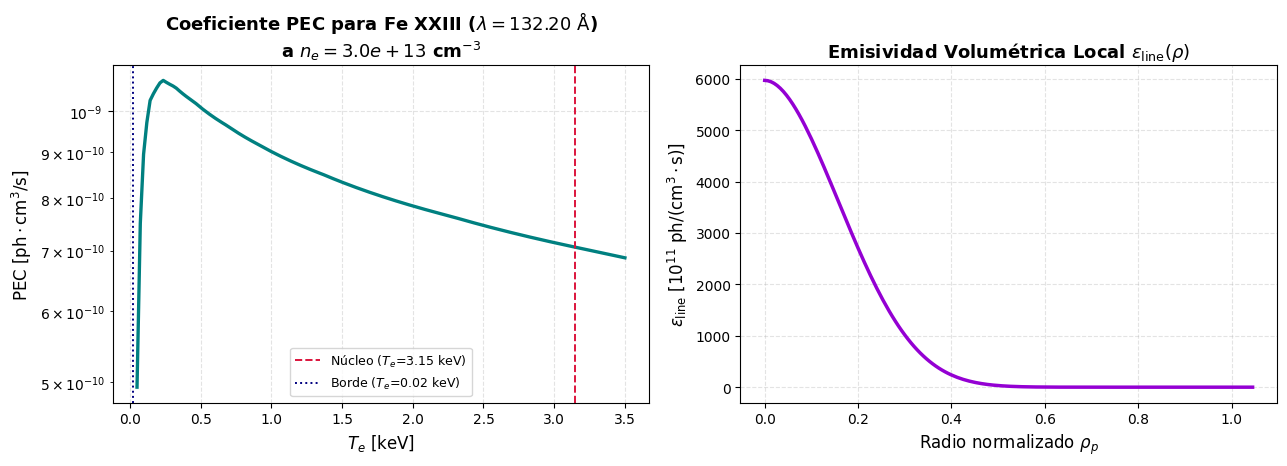

In [9]:
# Descargar / cargar archivo ADF15 de Fe XXIII desde OPEN-ADAS
pec_file = aurora.adas_files.get_adas_file_loc('transport_llu#fe22ic.dat', filetype='adf15')
trs = aurora.read_adf15(pec_file)

print(f"Archivo ADF15 cargado: {pec_file.split('/')[-1]}")
print(f"Total de líneas espectrales disponibles: {len(trs)}")

# Seleccionar la línea de mayor emisión por excitación (Fe XXIII, ~13.22 nm, consistente con Vogel et al. 2021)
tr_selected = trs.iloc[0]
wave_A = tr_selected['lambda [A]']
pec_func = tr_selected['log10 PEC fun']
print(f"Línea seleccionada : {wave_A:.4f} Å ({tr_selected['type']})")

# Evaluar el PEC en cada punto de nuestro perfil radial de EAST (ne, Te locales)
# — esto es lo que realmente alimenta la emisividad espacial de más abajo.
log10_ne_grid = np.log10(asim.ne[0, :])
log10_Te_grid = np.log10(asim.Te[0, :])

pec_profile = np.zeros(len(asim.rvol_grid))
for i in range(len(asim.rvol_grid)):
    # La función interpoladora devuelve log10(PEC)
    pec_profile[i] = 10**float(pec_func(log10_ne_grid[i], log10_Te_grid[i]))

# Densidad local del ion Fe22+ (Fe XXIII) al final de la simulación de referencia (sección 4.2)
nz_diff = steady_profiles["Difusión Pura (D=1, v=0)"]["nz_raw"]
n_Fe22 = nz_diff[:, 22, -1]  # cm^-3

# Emisividad volumétrica local: eps(r) = ne * n_ion * PEC  [ph / (cm^3 * s)]
emissivity_line = asim.ne[0, :] * n_Fe22 * pec_profile

# --- Panel 1: dependencia atómica pura del PEC con Te (a ne fija del núcleo) ---
# No tiene sentido físico mostrar el PEC en función del radio: el PEC es una
# propiedad atómica que depende de (ne, Te), no de rho directamente. Lo que
# varía con el radio es la emisividad (Panel 2), porque ahí sí entran ne(rho)
# y n_Fe22(rho). Aquí mostramos la curva PEC(Te) y dónde cae el núcleo/borde
# reales de nuestro perfil de EAST sobre esa curva.
ne_ref_cm3 = asim.ne[0, 0]   # ne del núcleo de nuestro perfil de EAST
Te_scan_eV = np.linspace(50.0, 3500.0, 150)
pec_vs_Te = np.array([10**float(pec_func(np.log10(ne_ref_cm3), np.log10(te))) for te in Te_scan_eV])

Te_core_eV = asim.Te[0, 0]
Te_edge_eV = asim.Te[0, -1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

ax1.plot(Te_scan_eV / 1e3, pec_vs_Te, color='teal', lw=2.4)
ax1.axvline(Te_core_eV / 1e3, color='crimson', linestyle='--', lw=1.4, label=f'Núcleo ($T_e$={Te_core_eV/1e3:.2f} keV)')
ax1.axvline(Te_edge_eV / 1e3, color='navy', linestyle=':', lw=1.4, label=f'Borde ($T_e$={Te_edge_eV/1e3:.2f} keV)')
ax1.set_xlabel(r'$T_e$ [keV]')
ax1.set_ylabel(r'PEC [$\mathrm{ph}\cdot\mathrm{cm}^3/\mathrm{s}$]')
ax1.set_title(f"Coeficiente PEC para Fe XXIII ($\\lambda = {wave_A:.2f}\\ \\mathrm{{\\AA}}$)\na $n_e={ne_ref_cm3:.1e}$ cm$^{{-3}}$", fontweight='bold')
ax1.set_yscale('log')
ax1.legend(fontsize=9)

ax2.plot(asim.rhop_grid, emissivity_line / 1e11, color='darkviolet', lw=2.5)
ax2.set_xlabel(r'Radio normalizado $\rho_p$')
ax2.set_ylabel(r'$\varepsilon_{\mathrm{line}}\ [10^{11}\ \mathrm{ph}/(\mathrm{cm}^3\cdot\mathrm{s})]$')
ax2.set_title(r"Emisividad Volumétrica Local $\varepsilon_{\mathrm{line}}(\rho)$", fontweight='bold')

plt.tight_layout()
plt.show()

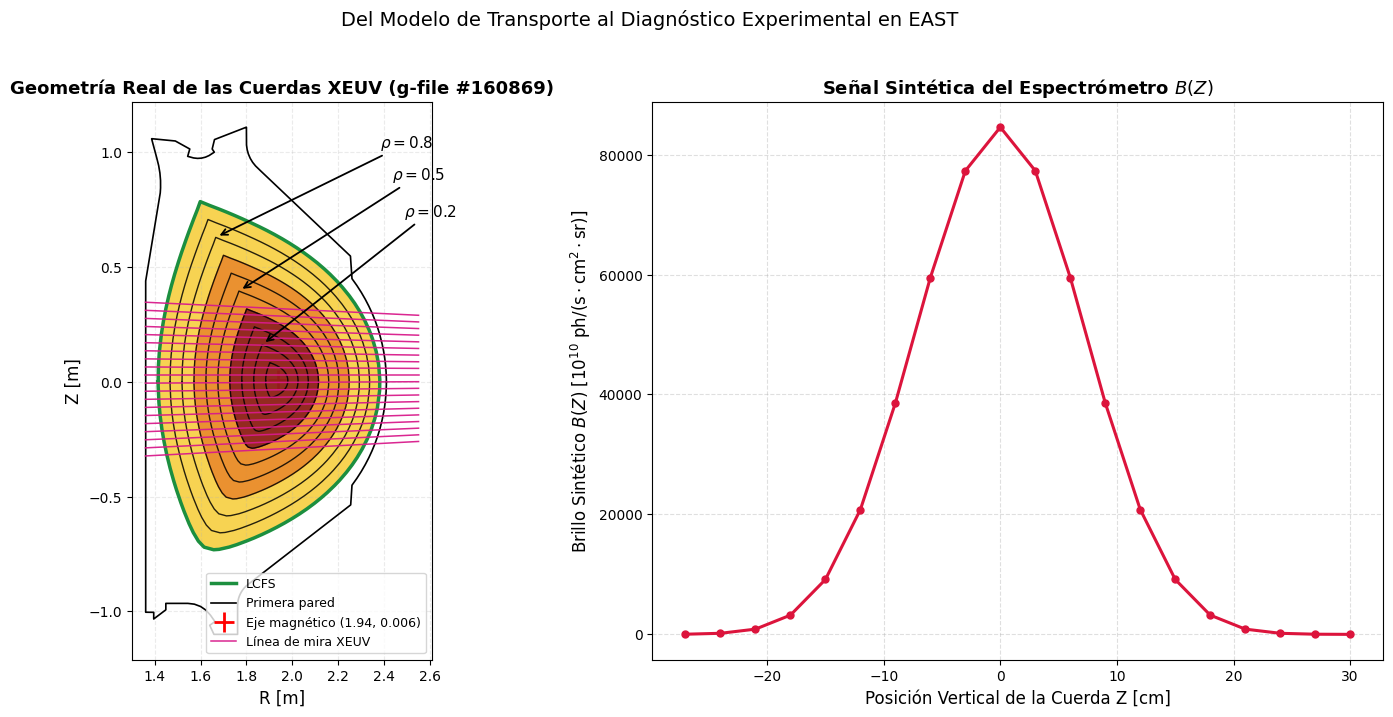

In [10]:
import scipy.integrate
from freeqdsk import geqdsk
from pathlib import Path

# =============================================================================
# Panel 1: Geometría REAL de las cuerdas XEUV_Long sobre el equilibrio EFIT
# (g-file real del disparo #160869, no un círculo esquemático)
# =============================================================================
GFILE = Path("gfiles") / "g160869.03960"
with open(GFILE) as f:
    geq = geqdsk.read(f)

Rb, Zb = np.asarray(geq.rbdry), np.asarray(geq.zbdry)   # LCFS real
Rax, Zax = geq.rmagx, geq.zmagx                          # eje magnético real

def scaled_lcfs(rho):
    """LCFS escalada por rho respecto al eje magnético (representación esquemática
    de las superficies internas, como en Vogel et al. 2021)."""
    return Rax + rho * (Rb - Rax), Zax + rho * (Zb - Zax)

# 20 cuerdas reales del XEUV_Long (mismo rango vertical que el instrumento: -27 a +30 cm)
Z_CHORDS_M  = np.linspace(-0.27, +0.30, 20)
R_PINHOLE   = 8.0
Z_PINHOLE   = 0.03
R_REF       = 2.35
R_CHORD_END = 1.36    # HFS: hasta la primera pared, sin cruzarla
R_PLOT_END  = 2.55

# =============================================================================
# Panel 2: Brillo sintético a lo largo de esas mismas 20 cuerdas
# (usa el modelo simplificado circular de Aurora, no el equilibrio 2D real —
# el Panel 1 muestra la forma real, el Panel 2 la predicción del modelo 1D)
# =============================================================================
a_minor_cm = asim.rvol_lcfs  # 45 cm
r_grid_cm  = asim.rvol_grid  # Grilla radial [cm]

z_chords_cm = Z_CHORDS_M * 100.0  # m -> cm
brightness_synth = np.zeros_like(z_chords_cm)

for i, z in enumerate(z_chords_cm):
    if np.abs(z) < a_minor_cm:
        l_max = np.sqrt(a_minor_cm**2 - z**2)
        l_path = np.linspace(-l_max, l_max, 150)
        r_eval = np.sqrt(l_path**2 + z**2)

        # Interpolar la emisividad radial a lo largo del camino óptico
        eps_eval = np.interp(r_eval, r_grid_cm, emissivity_line, left=0.0, right=0.0)

        # Integrar numéricamente a lo largo de la cuerda: B = (1 / 4pi) * integral eps dl
        brightness_synth[i] = (1.0 / (4.0 * np.pi)) * scipy.integrate.simpson(y=eps_eval, x=l_path)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# --- Panel 1: capas de color por región (esquemático, como Vogel 2018) ---
R_edge, Z_edge = scaled_lcfs(1.0)
R_mid,  Z_mid  = scaled_lcfs(0.7)
R_core, Z_core = scaled_lcfs(0.4)
ax1.fill(R_edge, Z_edge, color='#f5c518', alpha=0.75, zorder=1)
ax1.fill(R_mid,  Z_mid,  color='#e8862a', alpha=0.85, zorder=2)
ax1.fill(R_core, Z_core, color='#8a1f1f', alpha=0.90, zorder=3)

# superficies internas rho = 0.1 .. 0.9
for rho in np.linspace(0.1, 0.9, 9):
    Rs, Zs = scaled_lcfs(rho)
    ax1.plot(Rs, Zs, color='k', lw=1.0, alpha=0.85, zorder=4)

ax1.plot(Rb, Zb, color='#1c8f3f', lw=2.5, label='LCFS')
ax1.plot(geq.rlim, geq.zlim, color='k', lw=1.2, label='Primera pared')
ax1.plot(Rax, Zax, 'r+', ms=15, mew=2, label=f'Eje magnético ({Rax:.2f}, {Zax:.3f})')

# 20 cuerdas reales (fan desde el pinhole hasta la primera pared)
for i, z_ref in enumerate(Z_CHORDS_M):
    slope = (z_ref - Z_PINHOLE) / (R_REF - R_PINHOLE)
    z_s = Z_PINHOLE + slope * (R_PLOT_END - R_PINHOLE)
    z_e = Z_PINHOLE + slope * (R_CHORD_END - R_PINHOLE)
    ax1.plot([R_PLOT_END, R_CHORD_END], [z_s, z_e], color='#d81b8b', lw=1.1, alpha=0.95, zorder=6,
              label='Línea de mira XEUV' if i == 0 else None)

def top_point(rho):
    Rs, Zs = scaled_lcfs(rho)
    j = np.argmax(Zs)
    return float(Rs[j]), float(Zs[j])

for rho, (tx, ty) in [(0.8, (2.50, 1.02)), (0.5, (2.55, 0.88)), (0.2, (2.60, 0.72))]:
    R_t, Z_t = top_point(rho)
    ax1.annotate(rf'$\rho = {rho}$', xy=(R_t, Z_t), xytext=(tx, ty),
                 fontsize=11, fontweight='bold', color='k', ha='center',
                 arrowprops=dict(arrowstyle='->', color='k', lw=1.3, shrinkA=0, shrinkB=3), zorder=8)

ax1.set_aspect('equal')
ax1.set_xlabel('R [m]', fontsize=12)
ax1.set_ylabel('Z [m]', fontsize=12)
ax1.set_title("Geometría Real de las Cuerdas XEUV (g-file #160869)", fontweight='bold')
ax1.legend(fontsize=9, loc='lower right')
ax1.grid(alpha=0.25)

# --- Panel 2: brillo sintético a lo largo de las mismas 20 cuerdas ---
ax2.plot(z_chords_cm, brightness_synth / 1e10, 'o-', color='crimson', lw=2.2, markersize=5)
ax2.set_xlabel('Posición Vertical de la Cuerda Z [cm]')
ax2.set_ylabel(r'Brillo Sintético $B(Z)\ [10^{10}\ \mathrm{ph}/(\mathrm{s}\cdot\mathrm{cm}^2\cdot\mathrm{sr})]$')
ax2.set_title("Señal Sintética del Espectrómetro $B(Z)$", fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.suptitle("Del Modelo de Transporte al Diagnóstico Experimental en EAST", y=1.02)
plt.tight_layout()
plt.show()

### 7.1 PECs de Tungsteno: $W^{24+}$ a $W^{30+}$

Los PEC (*Photon Emissivity Coefficients*) no solo dependen de la línea elegida, sino fuertemente del estado de carga: a medida que se pela más el ion, la estructura atómica cambia y con ella la eficiencia de emisión. A modo de comparación con Fe XXIII, cargamos los archivos ADF15 de Tungsteno para los estados $W^{24+}$ a $W^{30+}$ (región cercana a Ni-like $W^{28+}$, un emisor EUV conocido) y graficamos, para la línea más intensa de cada uno, el PEC **en función de $T_e$** (a $n_e$ fija) — no en función del radio.

W26+  ->  línea más intensa: 48.23 Å  |  PEC máximo: 2.05e-10  |  pico en Te=0.94 keV, luego decrece a 94% del máximo hacia 2 keV
W27+  ->  línea más intensa: 47.66 Å  |  PEC máximo: 1.12e-09  |  pico en Te=1.01 keV, luego decrece a 96% del máximo hacia 2 keV
W28+  ->  línea más intensa: 48.29 Å  |  PEC máximo: 1.50e-09  |  pico en Te=0.15 keV, luego decrece a 60% del máximo hacia 2 keV
W29+  ->  línea más intensa: 48.40 Å  |  PEC máximo: 1.08e-09  |  pico en Te=0.39 keV, luego decrece a 91% del máximo hacia 2 keV
W30+  ->  línea más intensa: 49.19 Å  |  PEC máximo: 7.96e-10  |  pico en Te=0.82 keV, luego decrece a 95% del máximo hacia 2 keV


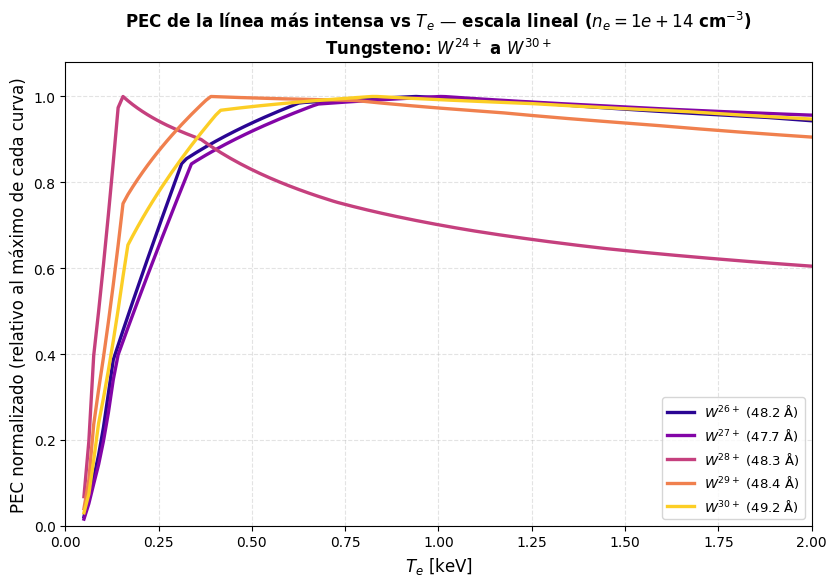

In [11]:
import aurora
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# PEC(Te) de Tungsteno para varios estados de carga (W24+ a W30+)
# Para cada estado: cargar su ADF15, elegir la línea más intensa a una
# referencia (Te=1500 eV, ne=1e14 cm^-3) y evaluar su PEC en función de Te.
# =============================================================================
W_CHARGE_STATES = range(26, 31)   # W24+ ... W30+
NE_REF_CM3 = 1e14                 # densidad de referencia fija
TE_REF_EV  = 1500.0               # Te de referencia para elegir la línea más intensa
Te_scan_eV = np.linspace(50.0, 2000.0, 150)   # escala lineal, 0-2 keV

pec_curves = {}   # z -> (lambda_A, PEC(Te_scan_eV))

for z in W_CHARGE_STATES:
    pec_file = aurora.adas_files.get_adas_file_loc(f'pec40#w_ic#w{z}.dat', filetype='adf15')
    trs = aurora.read_adf15(pec_file)

    # Elegir la línea más intensa a la referencia (Te_ref, ne_ref)
    pec_ref = np.array([
        row['log10 PEC fun'](np.log10(NE_REF_CM3), np.log10(TE_REF_EV)).item()
        for _, row in trs.iterrows()
    ])
    j = np.argmax(pec_ref)
    tr_strong = trs.iloc[j]
    lambda_A = tr_strong['lambda [A]']

    pec_vs_Te = np.array([
        10**tr_strong['log10 PEC fun'](np.log10(NE_REF_CM3), np.log10(te)).item()
        for te in Te_scan_eV
    ])
    pec_curves[z] = (lambda_A, pec_vs_Te)

    # Diagnóstico de tendencia real (no solo comparar el primer y último punto,
    # que puede ocultar un pico intermedio como el de W28+)
    peak_idx = np.argmax(pec_vs_Te)
    peak_Te_keV = Te_scan_eV[peak_idx] / 1e3
    if peak_idx == len(pec_vs_Te) - 1:
        tendencia = "creciente en todo 0-2 keV (no alcanza máximo en el rango)"
    else:
        frac_final = pec_vs_Te[-1] / pec_vs_Te[peak_idx]
        tendencia = f"pico en Te={peak_Te_keV:.2f} keV, luego decrece a {frac_final*100:.0f}% del máximo hacia 2 keV"
    print(f"W{z}+  ->  línea más intensa: {lambda_A:.2f} Å  |  PEC máximo: {pec_vs_Te.max():.2e}  |  {tendencia}")

# --- Gráfico: PEC(Te) normalizado al máximo de cada curva (escala lineal-lineal) ---
# El PEC absoluto varía ~3 órdenes de magnitud entre estados de carga; para ver
# la tendencia (creciente/decreciente) de TODAS en el mismo eje lineal, cada
# curva se normaliza a su propio máximo.
fig, ax = plt.subplots(figsize=(8.5, 6))
colors = plt.cm.plasma(np.linspace(0.05, 0.9, len(W_CHARGE_STATES)))

for (z, (lambda_A, pec_vs_Te)), c in zip(pec_curves.items(), colors):
    ax.plot(Te_scan_eV / 1e3, pec_vs_Te / pec_vs_Te.max(), color=c, lw=2.4,
            label=f'$W^{{{z}+}}$ ({lambda_A:.1f} Å)')

ax.set_xlim(0, 2.0)
ax.set_ylim(0, 1.08)
ax.set_xlabel(r'$T_e$ [keV]', fontsize=12)
ax.set_ylabel(r'PEC normalizado (relativo al máximo de cada curva)', fontsize=12)
ax.set_title(f'PEC de la línea más intensa vs $T_e$ — escala lineal ($n_e = {NE_REF_CM3:.0e}$ cm$^{{-3}}$)\nTungsteno: $W^{{24+}}$ a $W^{{30+}}$',
             fontweight='bold', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.35)
ax.legend(fontsize=9.5, loc='lower right')
plt.tight_layout()
plt.show()

## 8. Cómo se usa esto en la práctica: el problema inverso ($v/D$)

En mi trabajo de tesis para EAST, el objetivo no era solo correr la simulación hacia adelante, sino **extraer los perfiles de $D(\rho)$ y $v(\rho)$ a partir de los espectros medidos**:

```
 [ Perfiles propuestos D(ρ), v(ρ) ]
                │
                ▼
      Simulador Aurora  ─────── (<50 ms)
                │
                ▼
         nz(ρ, t) predicho
                │
                ▼
    Emisividad: ε(ρ) = ne · nz · PEC
                │
                ▼
       Integración de cuerdas
                │
                ▼
          B_sim(z, t)
                │
                ▼
  ¿B_sim calza con los datos del XEUV?
    ├── NO  ──>  El optimizador (Differential Evolution) propone otro v y D
    └── SÍ  ──>  ¡Convergencia! Tenemos los perfiles de transporte experimentales
```

Como Aurora corre en ~20 ms, es posible evaluar cientos o miles de combinaciones en pocos minutos.


## 9. Notas finales y ejercicios

1. **Efecto de la temperatura:** Si subimos $T_e(0)$ en EAST con ECRH de 2 keV a 4 keV, ¿qué pasa con la radiación de líneas del Argón en el núcleo? (Pista: el Argón se ioniza casi por completo a He-like y H-like).
2. **Degeneración de una sola línea:** Si solo mides una línea espectral (por ejemplo Fe XXIII), ¿cómo distingues si una caída en la señal central se debe a que las impurezas salieron ($v > 0$) o a que la temperatura subió y el ion se ionizó al estado siguiente? (Por esto en EAST se intenta medir varias líneas simultáneamente, método Shen 2019).
3. **Sensibilidad a $v/D$:** Prueba cambiar los valores de $D$ y $v$ en la sección 4 y mira cómo cambia la forma del perfil estacionario.
